# Compare `_add.pkl` verification metrics across datasets

Reloads the lightweight files written by section 8 of [`verify_add_cache_metrics.ipynb`](verify_add_cache_metrics.ipynb) and compares all available brains. This notebook does not load a cache or read cloud data.

In [1]:
import os, glob, re
import numpy as np
import pandas as pd

REPO = "/allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent"

## Comparisons

The saved results are loaded once, normalized into a single table, and plotted in
three views:

1. all brains at `mcl100`;
2. all brains at `mcl10`;
3. within each brain, `mcl100` versus `mcl10`.

A single plotting function produces every view, keeping metric definitions,
axis scaling, colors, and legends consistent. Legacy `<brain>_per_neuron.csv`
files remain readable when their matching summary contains `min_cable_length`.
If both a legacy file and a new MCL-qualified file describe the same rows, the
MCL-qualified file takes precedence.

5 brain/MCL configuration(s): 789202 · mcl100, 794491 · mcl100, 794493 · mcl100, 794495 · mcl100, 802449 · mcl100  (88 neurons total)


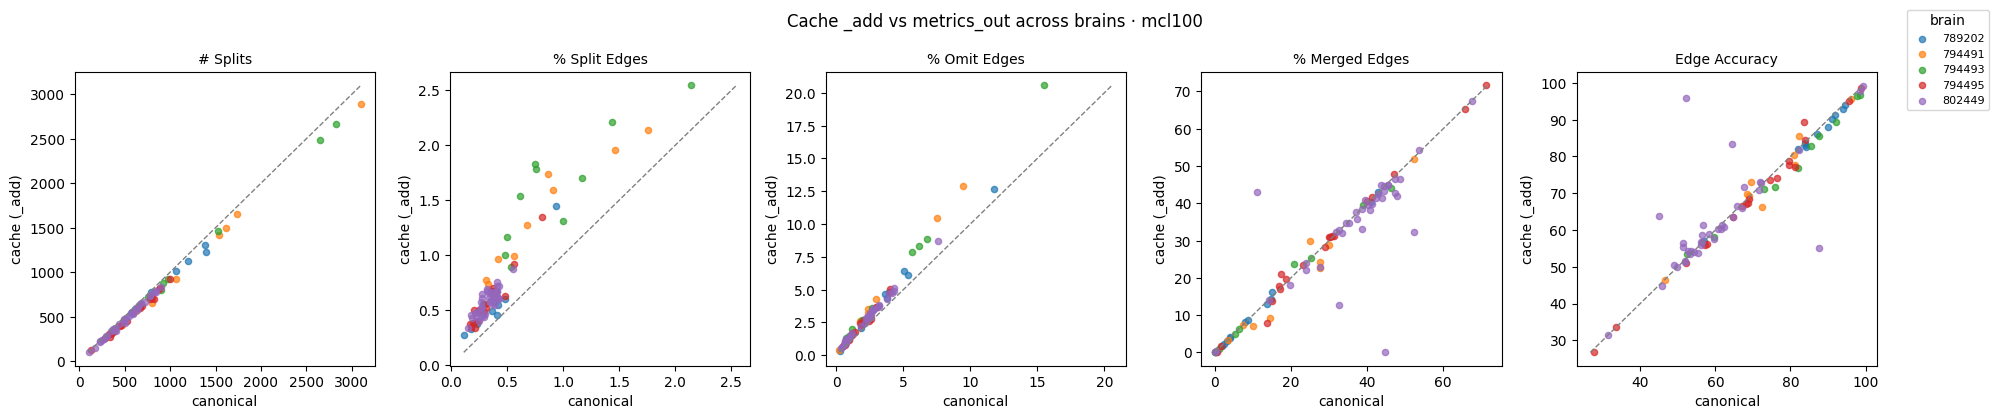

SKIP: Cache _add vs metrics_out across brains · mcl10 -- no matching saved results

Within-brain mcl100 vs mcl10:
  SKIP 789202: missing mcl10
  SKIP 794491: missing mcl10
  SKIP 794493: missing mcl10
  SKIP 794495: missing mcl10
  SKIP 802449: missing mcl10


In [2]:
import matplotlib.pyplot as plt

VERIFY_STATS_DIR = os.path.join(REPO, "exa-spim-agent/notebooks/verify_stats")
COMPARE_COLS = ["# Splits", "% Split Edges", "% Omit Edges",
                "% Merged Edges", "Edge Accuracy"]
MCL_ORDER = (100, 10)


def load_per_neuron(path):
    """Load one saved table and attach its authoritative MCL value."""
    df = pd.read_csv(path)
    df["brain_id"] = df["brain_id"].astype(str)
    mcl_match = re.search(r"_mcl(\d+)_per_neuron\.csv$", path)

    if "min_cable_length" not in df.columns:
        if mcl_match:
            mcl = int(mcl_match.group(1))
        else:
            brain_ids = df["brain_id"].unique()
            assert len(brain_ids) == 1, f"cannot infer one brain from legacy file {path}"
            summary_path = os.path.join(VERIFY_STATS_DIR, f"{brain_ids[0]}_summary.csv")
            assert os.path.exists(summary_path), (
                f"legacy file {path} has no min_cable_length column and no matching summary"
            )
            summary = pd.read_csv(summary_path)
            assert "min_cable_length" in summary.columns and len(summary) == 1, (
                f"cannot infer min_cable_length from {summary_path}"
            )
            mcl = int(summary["min_cable_length"].iloc[0])
        df.insert(2, "min_cable_length", mcl)

    df["min_cable_length"] = df["min_cable_length"].astype(int)
    df["_mcl_named"] = bool(mcl_match)
    return df


def plot_metric_grid(data, group_col, group_order, colors, title, legend_title):
    """Plot cache versus canonical values for all metrics using one grouping."""
    present = set(data[group_col].unique())
    groups = [group for group in group_order if group in present]
    if not groups:
        print(f"SKIP: {title} -- no matching saved results")
        return None

    fig, axes = plt.subplots(1, len(COMPARE_COLS),
                             figsize=(4 * len(COMPARE_COLS), 4.2))
    for ax, col in zip(axes, COMPARE_COLS):
        bounds = []
        for group in groups:
            subset = data[data[group_col] == group]
            x = subset[f"{col}_canon"].to_numpy(dtype=float)
            y = subset[f"{col}_cache"].to_numpy(dtype=float)
            finite = np.isfinite(x) & np.isfinite(y)
            if not finite.any():
                continue
            x, y = x[finite], y[finite]
            ax.scatter(x, y, s=20, alpha=0.7, color=colors[group], label=str(group))
            bounds.extend((x.min(), x.max(), y.min(), y.max()))

        if bounds:
            lo, hi = min(bounds), max(bounds)
            if lo == hi:
                lo, hi = lo - 0.5, hi + 0.5
            ax.plot([lo, hi], [lo, hi], "--", color="grey", lw=1)
        ax.set_xlabel("canonical")
        ax.set_ylabel("cache (_add)")
        ax.set_title(col, fontsize=10)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, title=legend_title, loc="upper right",
                   bbox_to_anchor=(1.0, 1.0), fontsize=8)
    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0, 0.95, 1])
    plt.show()
    return fig


# Load and normalize all saved results once.
neuron_files = sorted(glob.glob(os.path.join(VERIFY_STATS_DIR, "*_per_neuron.csv")))
assert neuron_files, f"no *_per_neuron.csv under {VERIFY_STATS_DIR} -- run section 8 first."
all_neurons = pd.concat([load_per_neuron(path) for path in neuron_files],
                        ignore_index=True)

# Prefer MCL-qualified artifacts over equivalent legacy rows.
all_neurons = (all_neurons.sort_values("_mcl_named")
               .drop_duplicates(["brain_id", "min_cable_length", "neuron"], keep="last")
               .drop(columns="_mcl_named"))
brains = sorted(all_neurons["brain_id"].unique())
configurations = (all_neurons[["brain_id", "min_cable_length"]]
                  .drop_duplicates()
                  .sort_values(["brain_id", "min_cable_length"]))
configuration_labels = [
    f"{row.brain_id} · mcl{row.min_cable_length}"
    for row in configurations.itertuples(index=False)
]
print(f"{len(configurations)} brain/MCL configuration(s): "
      f"{', '.join(configuration_labels)}  ({len(all_neurons)} neurons total)")

# Keep each brain's color consistent between the mcl100 and mcl10 overview plots.
brain_cmap = plt.get_cmap("tab10" if len(brains) <= 10 else "tab20")
brain_colors = {brain: brain_cmap(i % brain_cmap.N)
                for i, brain in enumerate(brains)}

# 1) all mcl100 brains, then 2) all mcl10 brains.
overview_figures = {}
for mcl in MCL_ORDER:
    subset = all_neurons[all_neurons["min_cable_length"] == mcl]
    overview_figures[mcl] = plot_metric_grid(
        subset,
        group_col="brain_id",
        group_order=brains,
        colors=brain_colors,
        title=f"Cache _add vs metrics_out across brains · mcl{mcl}",
        legend_title="brain",
    )

# 3) within each brain, compare mcl100 with mcl10 using fixed MCL colors.
mcl_colors = {100: "#d97706", 10: "#2563eb"}
within_brain_figures = {}
print("\nWithin-brain mcl100 vs mcl10:")
for brain in brains:
    subset = all_neurons[all_neurons["brain_id"] == brain]
    available = set(subset["min_cable_length"].unique())
    missing = [mcl for mcl in MCL_ORDER if mcl not in available]
    if missing:
        print(f"  SKIP {brain}: missing {', '.join(f'mcl{mcl}' for mcl in missing)}")
        continue
    print(f"  PLOT {brain}: mcl100 and mcl10")
    within_brain_figures[brain] = plot_metric_grid(
        subset,
        group_col="min_cable_length",
        group_order=MCL_ORDER,
        colors=mcl_colors,
        title=f"Cache _add vs metrics_out · brain {brain} · mcl100 vs mcl10",
        legend_title="MCL (µm)",
    )